## Import Libararies

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itables
from sqlalchemy import create_engine


## Create Connection

In [2]:
engine = create_engine(
    r'mssql+pyodbc://DESKTOP-931U322\SQLEXPRESS/Olist_DB'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&trusted_connection=yes'
)

## Load tables

In [3]:
orders        = pd.read_sql('SELECT * FROM orders',        engine)
order_items   = pd.read_sql('SELECT * FROM order_items',   engine)
order_reviews = pd.read_sql('SELECT * FROM order_reviews', engine)
order_payments= pd.read_sql('SELECT * FROM order_payments',engine)
customers     = pd.read_sql('SELECT * FROM customers',     engine)
sellers       = pd.read_sql('SELECT * FROM sellers',       engine)
products      = pd.read_sql('SELECT * FROM products',      engine)

## Q1 — What is the order status distribution?

In [ ]:
status_dist = (
    orders['order_status']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'order_count'})
)
status_dist['pct'] = (status_dist['order_count'] / status_dist['order_count'].sum() * 100).round(2)

itables.show(status_dist)
 

Loading ITables v2.5.2 from the internet... (need help?)


## Q2 — How did order volume and revenue grow month by month?

Loading ITables v2.5.2 from the internet... (need help?)


C:\Users\w\AppData\Local\Temp\ipykernel_9788\326441799.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly['year_month'].astype(str), rotation=45, ha='right')


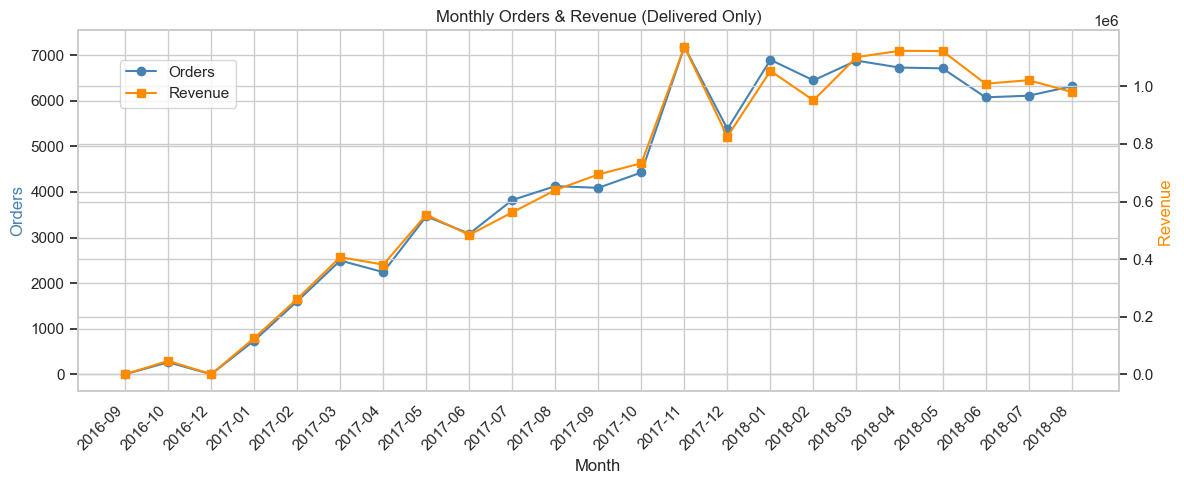

In [12]:
delivered       = orders[orders['order_status'] == 'delivered'].copy()
delivered_items = delivered.merge(order_items, on='order_id')
delivered_items['order_total'] = delivered_items['price'] + delivered_items['freight_value']
delivered_items['year_month']  = delivered_items['order_purchase_timestamp'].dt.to_period('M')
 
monthly = (
    delivered_items
    .groupby('year_month')
    .agg(
        total_orders  =('order_id',    'nunique'),
        total_revenue =('order_total', 'sum')
    )
    .reset_index()
)
monthly['total_revenue'] = monthly['total_revenue'].round(2)

itables.show(monthly)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
 
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(monthly['year_month'].astype(str), monthly['total_orders'],
         color='steelblue', marker='o', label='Orders')
ax2.plot(monthly['year_month'].astype(str), monthly['total_revenue'],
         color='darkorange', marker='s', label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Orders', color='steelblue')
ax2.set_ylabel('Revenue ', color='darkorange')
ax1.set_xticklabels(monthly['year_month'].astype(str), rotation=45, ha='right')
ax1.set_title('Monthly Orders & Revenue (Delivered Only)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()

## Q3 — What are the top 10 product categories by revenue?

In [ ]:
cat_revenue = (
    delivered_items
    .merge(products[['product_id', 'product_category']], on='product_id')
    .groupby('product_category')
    .agg(
        total_revenue=('order_total', 'sum'),
        total_orders =('order_id',    'nunique')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
    .head(10)
)
cat_revenue['total_revenue'] = cat_revenue['total_revenue'].round(2)

cat_revenue = cat_revenue.reset_index(drop=True)
 
itables.show(cat_revenue)

Loading ITables v2.5.2 from the internet... (need help?)


## Q4 — What is the average, min, max, and spread of order value?

In [19]:
 
order_totals = (
    delivered_items
    .groupby('order_id')['order_total']
    .sum()
)

itables.show(order_totals.describe().round(2))


Loading ITables v2.5.2 from the internet... (need help?)


## Q5 — What percentage of orders were delivered on time?

In [21]:
delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days
 
delivered['delivery_status'] = delivered['delay_days'].apply(
    lambda x: 'On Time / Early' if x <= 0 else 'Late'
)
 
ontime = (
    delivered['delivery_status']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'order_count'})
)
ontime['pct'] = (ontime['order_count'] / ontime['order_count'].sum() * 100).round(2)

print(ontime.to_string(index=False))

delivery_status  order_count   pct
On Time / Early        89936 93.22
           Late         6542  6.78


## Q6 — Which states generate the most revenue?

In [ ]:

state_revenue = (
    delivered_items
    .merge(customers[['customer_id', 'customer_state']], on='customer_id')
    .groupby('customer_state')
    .agg(
        total_revenue=('order_total', 'sum'),
        total_orders =('order_id',    'nunique')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
    .head(10)
)
state_revenue['total_revenue'] = state_revenue['total_revenue'].round(2)
state_revenue = state_revenue.reset_index(drop=True)


itables.show(state_revenue)

Loading ITables v2.5.2 from the internet... (need help?)


## Q7 — What is the overall review score distribution?

Loading ITables v2.5.2 from the internet... (need help?)


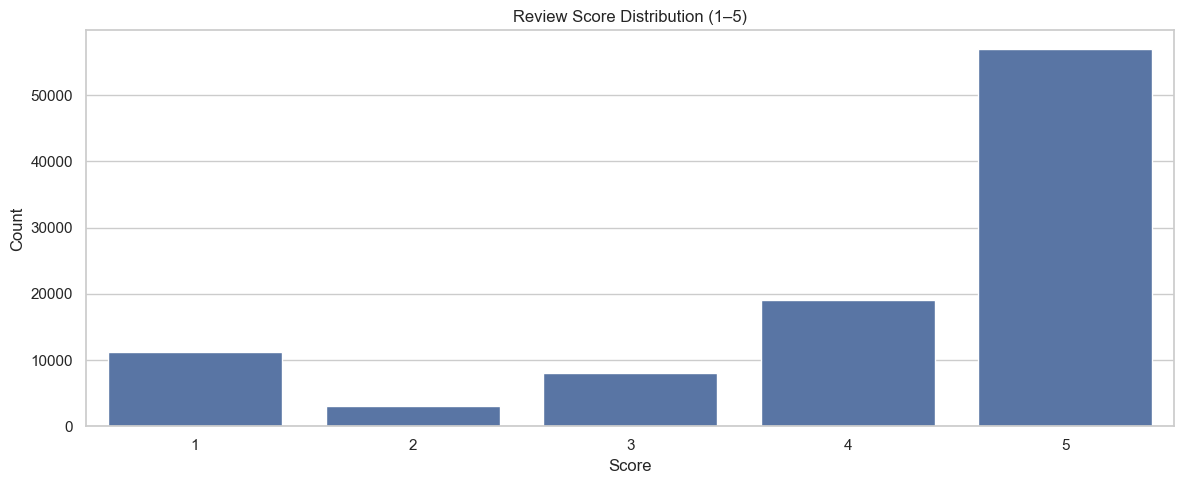

In [27]:

score_dist = (
    order_reviews['review_score']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'count': 'review_count'})
)
score_dist['pct'] = (score_dist['review_count'] / score_dist['review_count'].sum() * 100).round(2)
score_dist = score_dist.reset_index(drop=True)

itables.show(score_dist)
 
fig, ax = plt.subplots()
sns.barplot(data=score_dist, x='review_score', y='review_count', ax=ax)
ax.set_title('Review Score Distribution (1–5)')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Q8 — Does delivery delay actually impact review scores?

In [28]:
 
delay_score = (
    delivered[['order_id', 'delay_days']]
    .merge(order_reviews[['order_id', 'review_score']], on='order_id')
)
 
delay_score['delay_bucket'] = pd.cut(
    delay_score['delay_days'],
    bins=[-float('inf'), 0, 7, float('inf')],
    labels=['On Time / Early', 'Late 1–7 days', '8+ days late']
)
 
delay_impact = (
    delay_score
    .groupby('delay_bucket', observed=True)
    .agg(
        avg_score   =('review_score', 'mean'),
        order_count =('order_id',     'count')
    )
    .reset_index()
)
delay_impact['avg_score'] = delay_impact['avg_score'].round(2)

delay_impact = delay_impact.reset_index(drop=True)
itables.show(delay_impact)

Loading ITables v2.5.2 from the internet... (need help?)


## Q9 — What payment methods do customers prefer?

In [31]:
 
payment_dist = (
    order_payments
    .drop_duplicates(subset=['order_id', 'payment_type'])
    .groupby('payment_type')
    .agg(order_count=('order_id', 'count'))
    .reset_index()
    .sort_values('order_count', ascending=False)
)
payment_dist['pct'] = (payment_dist['order_count'] / payment_dist['order_count'].sum() * 100).round(4)
 
payment_dist = payment_dist.reset_index(drop=True)
itables.show(payment_dist)


Loading ITables v2.5.2 from the internet... (need help?)


## Q10 — What percentage of customers are repeat buyers?

In [32]:
customer_orders = (
    customers[['customer_id', 'customer_unique_id']]
    .merge(orders[['order_id', 'customer_id']], on='customer_id')
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'order_count'})
)
 
customer_orders['customer_type'] = customer_orders['order_count'].apply(
    lambda x: 'Repeat' if x > 1 else 'One-time'
)
 
repeat_dist = (
    customer_orders['customer_type']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'customer_count'})
)
repeat_dist['pct'] = (repeat_dist['customer_count'] / repeat_dist['customer_count'].sum() * 100).round(2)

repeat_dist = repeat_dist.reset_index(drop=True)
itables.show(repeat_dist)

Loading ITables v2.5.2 from the internet... (need help?)
